# Ignition Zero: O Início da Aurora
## Relatório Operacional de Pré-Decolagem

**Autor:** Célio Carlos Pereira Junior (RM: 574595)
**Curso:** Ciência da Computação (Online)


## 5.1 Organização e descrição da telemetria

A tabela abaixo apresenta os dados de telemetria monitorados durante a fase de pré-decolagem da nave Aurora Siger, com seus respectivos limites seguros de operação.

| Dado | Valor exemplo | Limite mínimo | Limite máximo | Situação |
|---|---|---|---|---|
| Temperatura interna | 78°C | -50°C | +80°C | Dentro da faixa |
| Temperatura externa | -280°C | -270°C | -100°C | Fora da faixa (abaixo do mínimo) |
| Integridade estrutural | 1 | Deve ser igual a 1 (íntegra) | — | Dentro do esperado |
| Nível de energia | 85% | 60% | 100% | Dentro da faixa |
| Pressão dos tanques | 320 PSI | 150 PSI | 300 PSI | Fora da faixa (acima do máximo) |
| Status dos módulos críticos | ON/ON/ON | Todos ON | — (crítico se algum OFF) | Dentro do esperado |

**Observação sobre a integridade estrutural:** por ser um dado booleano (0 ou 1), o critério de segurança é uma condição de igualdade (`integridade == 1`), e não um intervalo mínimo/máximo como as demais variáveis.


## 5.2 Algoritmo de verificação

O algoritmo de verificação analisa, em sequência, cada dado de telemetria coletado. Se qualquer verificação falhar, a decolagem será considerada abortada. O algoritmo continua as verificações para identificar e reportar todas as condições fora dos limites, permitindo que, em caso de múltiplas falhas, todos os motivos sejam apresentados. Somente se todas as verificações forem aprovadas o sistema libera "PRONTO PARA DECOLAR".

**Fluxograma:**


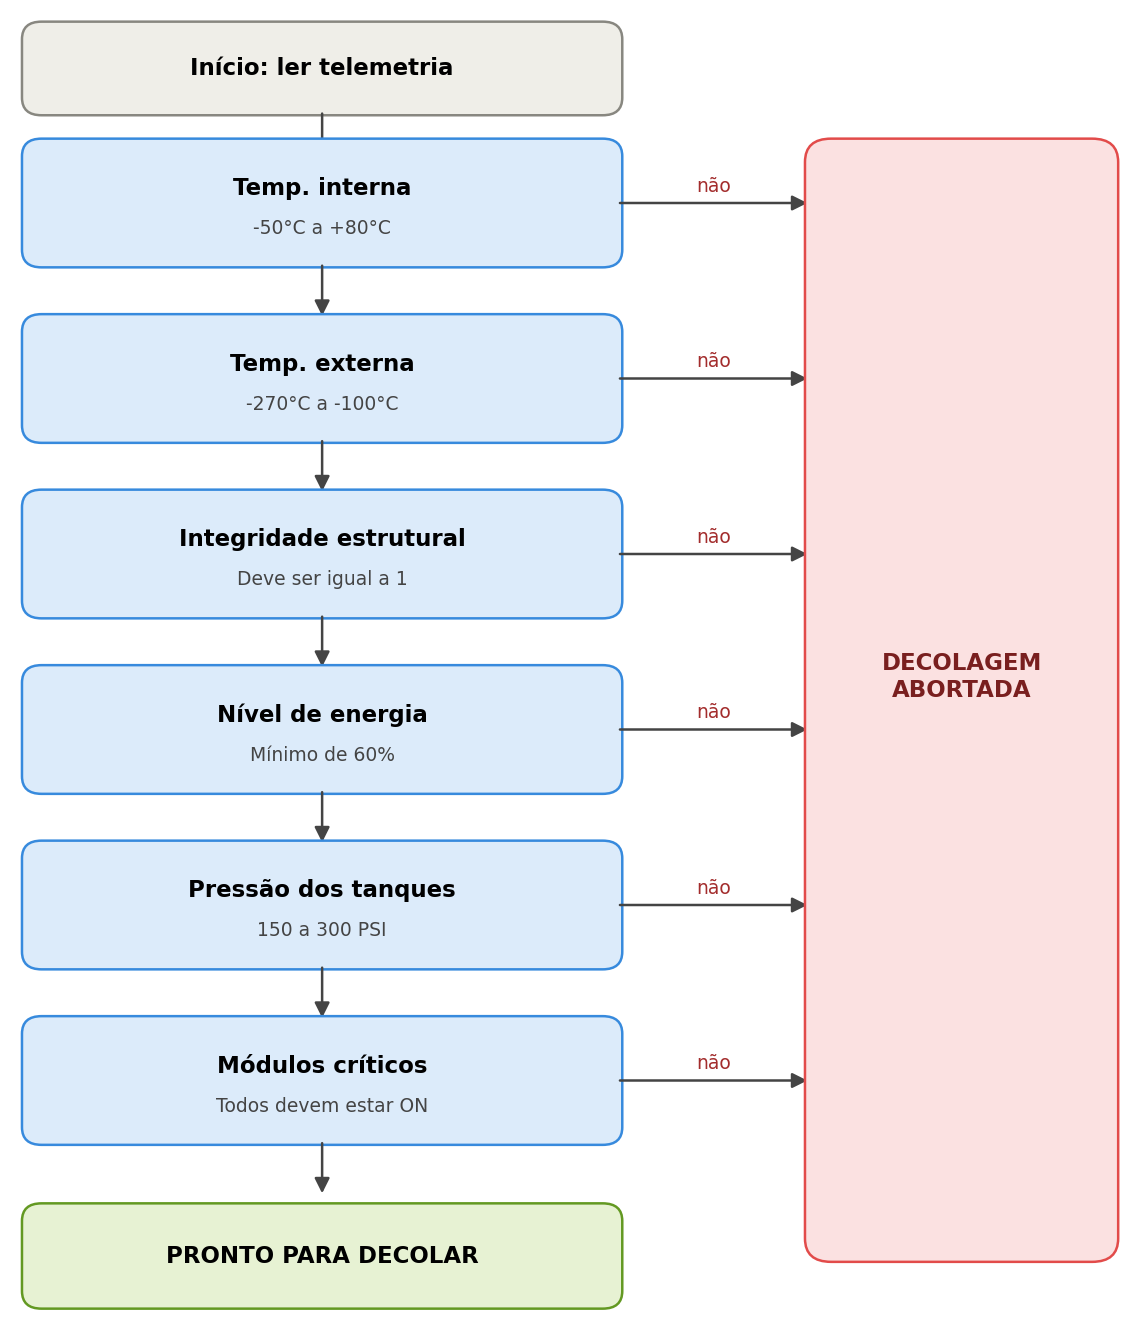

In [ ]:
from IPython.display import Image, display
import os

caminho_imagem = "fluxograma-verificacao.png"
if os.path.exists(caminho_imagem):
    display(Image(filename=caminho_imagem, width=550))
else:
    print("Imagem não encontrada nesta sessão.")
    print("O fluxograma está disponível no arquivo 'fluxograma-verificacao.png' deste repositório,")
    print("e também no relatório em PDF (Figura 1).")

*Figura 1 — Fluxograma do algoritmo de verificação de pré-decolagem*

**Pseudocódigo (equivalente ao fluxograma acima):**

```
INÍCIO

Ler dados da telemetria

Se temperatura interna estiver fora da faixa segura (-50°C a +80°C):
    DECOLAGEM ABORTADA

Senão se temperatura externa estiver fora da faixa segura (-270°C a -100°C):
    DECOLAGEM ABORTADA

Senão se integridade estrutural for diferente de 1:
    DECOLAGEM ABORTADA

Senão se energia for inferior a 60%:
    DECOLAGEM ABORTADA

Senão se pressão dos tanques estiver fora da faixa segura (150 a 300 PSI):
    DECOLAGEM ABORTADA

Senão se algum módulo crítico estiver desligado:
    DECOLAGEM ABORTADA

Senão:
    PRONTO PARA DECOLAR

FIM
```


## 5.3 Script em Python

Célula abaixo implementa a lógica do algoritmo, simulando a leitura dos dados, a execução das verificações e a impressão do resultado final.

In [ ]:
# ===== 1. LEITURA DOS DADOS =====
telemetria = {
    "temperatura_interna": 78,      # °C
    "temperatura_externa": -280,    # °C
    "integridade_estrutural": 1,    # 0 ou 1
    "energia": 85,                  # %
    "pressao_tanques": 320,         # PSI
    "modulos_criticos": True,       # True = todos ON
}

# ===== 2. FAIXAS SEGURAS =====
LIMITES = {
    "temperatura_interna": (-50, 80),
    "temperatura_externa": (-270, -100),
    "energia": (60, 100),
    "pressao_tanques": (150, 300),
}

# ===== 3. EXECUÇÃO DAS VERIFICAÇÕES =====
falhas = []

def verificar_faixa(nome_exibicao, valor, minimo, maximo):
    if valor < minimo or valor > maximo:
        falhas.append(f"{nome_exibicao}: {valor} fora da faixa segura ({minimo} a {maximo})")

verificar_faixa("Temperatura interna", telemetria["temperatura_interna"], *LIMITES["temperatura_interna"])
verificar_faixa("Temperatura externa", telemetria["temperatura_externa"], *LIMITES["temperatura_externa"])
verificar_faixa("Energia", telemetria["energia"], *LIMITES["energia"])
verificar_faixa("Pressão dos tanques", telemetria["pressao_tanques"], *LIMITES["pressao_tanques"])

if telemetria["integridade_estrutural"] != 1:
    falhas.append(f"Integridade estrutural: {telemetria['integridade_estrutural']} (esperado: 1)")

if telemetria["modulos_criticos"] is not True:
    falhas.append("Módulos críticos: nem todos estão ON")

# ===== 4. RESULTADO FINAL IMPRESSO =====
print("=" * 45)
print("RELATÓRIO DE VERIFICAÇÃO — PRÉ-DECOLAGEM")
print("=" * 45)

if falhas:
    print("\nSTATUS: DECOLAGEM ABORTADA\n")
    print("Motivo(s):")
    for f in falhas:
        print(f" - {f}")
else:
    print("\nSTATUS: PRONTO PARA DECOLAR")
    print("\nTodas as verificações foram aprovadas.")

print("=" * 45)


RELATÓRIO DE VERIFICAÇÃO — PRÉ-DECOLAGEM

STATUS: DECOLAGEM ABORTADA

Motivo(s):
 - Temperatura externa: -280 fora da faixa segura (-270 a -100)
 - Pressão dos tanques: 320 fora da faixa segura (150 a 300)


O script testa todas as verificações antes de decidir o resultado final, acumulando os motivos de falha em uma lista (`falhas`) em vez de interromper na primeira condição não atendida. Dessa forma, se houver mais de uma condição fora da faixa segura simultaneamente, todos os motivos são reportados, não apenas o primeiro identificado.

**Cenário de contraste** (teste adicional, valores hipotéticos totalmente dentro da faixa, para comprovar que o script também aprova corretamente quando não há falhas):

In [ ]:
telemetria_teste = {
    "temperatura_interna": 45,
    "temperatura_externa": -200,
    "integridade_estrutural": 1,
    "energia": 85,
    "pressao_tanques": 250,
    "modulos_criticos": True,
}

falhas_teste = []

def verificar_faixa_teste(nome, valor, minimo, maximo):
    if valor < minimo or valor > maximo:
        falhas_teste.append(f"{nome}: {valor} fora da faixa segura ({minimo} a {maximo})")

for chave, nome in [
    ("temperatura_interna", "Temperatura interna"),
    ("temperatura_externa", "Temperatura externa"),
    ("energia", "Energia"),
    ("pressao_tanques", "Pressão dos tanques"),
]:
    verificar_faixa_teste(nome, telemetria_teste[chave], *LIMITES[chave])

if telemetria_teste["integridade_estrutural"] != 1:
    falhas_teste.append("Integridade estrutural fora do esperado")
if telemetria_teste["modulos_criticos"] is not True:
    falhas_teste.append("Módulos críticos: nem todos estão ON")

print("=" * 45)
print("RELATÓRIO DE VERIFICAÇÃO — PRÉ-DECOLAGEM")
print("=" * 45)
if falhas_teste:
    print("\nSTATUS: DECOLAGEM ABORTADA\n")
    print("Motivo(s):")
    for f in falhas_teste:
        print(f" - {f}")
else:
    print("\nSTATUS: PRONTO PARA DECOLAR")
    print("\nTodas as verificações foram aprovadas.")
print("=" * 45)


RELATÓRIO DE VERIFICAÇÃO — PRÉ-DECOLAGEM

STATUS: PRONTO PARA DECOLAR

Todas as verificações foram aprovadas.


## 5.4 Análise energética

**Nota:** como a Aurora Siger é uma nave fictícia, os valores abaixo foram definidos hipoteticamente para permitir os cálculos pedidos.

- Capacidade total: 1000 kWh
- Carga atual: 85%
- Consumo estimado na decolagem: 220 kWh
- Perdas energéticas: 8%
- Consumo operacional médio: 100 kWh/h

In [ ]:
capacidade_total = 1000       # kWh
carga_atual_pct = 85          # %
consumo_decolagem = 220       # kWh
perdas_pct = 8                # %
consumo_operacional = 100     # kWh/h

energia_disponivel = capacidade_total * (carga_atual_pct / 100)
perdas_kwh = energia_disponivel * (perdas_pct / 100)
energia_liquida = energia_disponivel - perdas_kwh
energia_restante = energia_liquida - consumo_decolagem
autonomia_horas = energia_restante / consumo_operacional

print(f"Energia disponível: {energia_disponivel} kWh")
print(f"Perdas energéticas: {perdas_kwh} kWh")
print(f"Energia líquida: {energia_liquida} kWh")
print(f"Energia restante após decolagem: {energia_restante} kWh")
print(f"Autonomia estimada: {autonomia_horas:.2f} horas")


Energia disponível: 850.0 kWh
Perdas energéticas: 68.0 kWh
Energia líquida: 782.0 kWh
Energia restante após decolagem: 562.0 kWh
Autonomia estimada: 5.62 horas


**Conclusão:** considerando os parâmetros hipotéticos definidos para esta simulação, a nave possui 562 kWh de energia restante após a decolagem. Considerando ainda um consumo operacional médio hipotético de 100 kWh/h, isso corresponde a uma autonomia estimada de aproximadamente 5h37min.

## 5.5 Análise assistida por IA

**Prompt utilizado:**

> Analise os dados de telemetria da nave Aurora Siger considerando os limites operacionais definidos neste projeto. Classifique cada parâmetro como normal, atenção ou crítico; identifique possíveis anomalias e apresente sugestões de risco. A análise deve ser considerada complementar às verificações determinísticas do sistema e não deve substituir os critérios de autorização do lançamento.

**Critério de classificação:** cada valor numérico foi comparado à sua faixa segura, calculando a distância percentual até o limite mais próximo, segundo a fórmula:

```
Margem percentual = (distância até o limite mais próximo ÷ amplitude total da faixa) × 100
```

Valores fora da faixa foram classificados como "Crítico"; valores com margem inferior a 15% em relação a um limite, como "Atenção"; os demais, como "Normal".

**Classificação dos dados:**

| Parâmetro | Valor | Margem até o limite mais próximo | Classificação |
|---|---|---|---|
| Temperatura interna | 78°C | 1,5% | Atenção |
| Temperatura externa | -280°C | Fora da faixa (10°C abaixo do mínimo) | Crítico |
| Integridade estrutural | 1 | — (condição booleana) | Normal (aprovado) |
| Energia | 85% | 37,5% | Normal |
| Pressão dos tanques | 320 PSI | Fora da faixa (20 PSI acima do máximo) | Crítico |
| Módulos críticos | ON/ON/ON | — (condição booleana) | Normal (aprovado) |

**Identificação de anomalias:** foram identificadas duas condições críticas: temperatura externa abaixo do limite mínimo e pressão dos tanques acima do limite máximo. Além de uma condição de atenção na temperatura interna, muito próxima do seu limite superior.

Chama a atenção uma possível relação operacional entre a temperatura externa crítica e a temperatura interna em atenção: a exposição a uma temperatura externa abaixo do limite operacional plausivelmente exige maior esforço do sistema de controle térmico da nave para compensar a perda de calor para o ambiente, o que poderia contribuir para explicar por que a temperatura interna está próxima do seu próprio limite máximo. Como se trata de uma única leitura de telemetria (e não de uma série temporal), essa relação é uma hipótese plausível, não uma correlação demonstrada.

**Sugestões de risco:** com duas condições críticas confirmadas, a recomendação é o aborto da decolagem. Recomenda-se investigar o sistema de controle térmico como possível causa raiz comum das duas anomalias de temperatura, em vez de tratá-las isoladamente. A pressão elevada nos tanques deve ser investigada separadamente, já que não há indício de relação direta com o quadro térmico.

**Observação importante:** esta análise é complementar às verificações determinísticas do sistema de bordo e não substitui os critérios objetivos de autorização de lançamento. A decisão final deve permanecer a cargo do sistema de regras fixas, que segue faixas de segurança predefinidas e auditáveis.

## 5.6 Reflexão crítica

### Ética e responsabilidade

O desenvolvimento deste projeto evidenciou uma distinção importante entre sistemas de decisão automatizados e sistemas de apoio à decisão. O algoritmo de verificação (seções 5.2 e 5.3) toma uma decisão binária e determinística, baseada em regras fixas e auditáveis: qualquer parâmetro fora da faixa segura definida neste projeto resulta em aborto da decolagem, sem exceções. Já a análise assistida por IA (seção 5.5) foi deliberadamente estruturada para ser complementar, e não decisória. Ela classifica, contextualiza e sugere, mas não autoriza nem impede o lançamento.

Essa separação não é apenas uma escolha técnica, mas uma escolha ética. Delegar a decisão final de segurança a um sistema de IA, sem regras determinísticas e auditáveis por trás, criaria um risco real: um modelo pode interpretar incorretamente um cenário, sofrer de dados de treinamento enviesados ou até ser levado a otimizar métricas de forma indesejada, sem que fique claro por que uma decisão foi tomada. Manter a autorização de lançamento sob um sistema de regras fixas e transparentes garante que qualquer decisão possa ser explicada e verificada (um requisito básico de responsabilidade em sistemas cujo erro pode custar vidas ou recursos significativos).

### Impacto social da exploração espacial

A exploração espacial carrega uma tensão real entre benefícios amplos e custos concentrados. Por um lado, ela historicamente impulsiona avanços tecnológicos que se difundem para outras áreas (comunicação, materiais, medicina), além de gerar conhecimento científico de valor coletivo. Por outro lado, os recursos financeiros e humanos investidos em missões espaciais são substanciais, e nem sempre é evidente que a distribuição dos benefícios seja equitativa. Grande parte da população mundial não tem acesso direto às tecnologias ou às oportunidades geradas por esse setor, ao mesmo tempo em que recursos públicos são direcionados a esses projetos.

Isso não significa que a exploração espacial careça de valor, mas sim que sua justificativa social exige transparência sobre custos, prioridades e sobre quem efetivamente se beneficia dos avanços obtidos.

### Sustentabilidade tecnológica

A análise energética (seção 5.4) deste projeto, ainda que simplificada, ilustra um princípio mais amplo: sistemas tecnológicos operam sob restrições reais de energia, e cada decisão de engenharia, inclusive decisões de software que podem contribuir para a eficiência de sistemas tecnológicos mais amplos, tem implicações no consumo de recursos. Em um ambiente como o espaço, onde a energia é escassa e cara de gerar, essa restrição se torna ainda mais evidente do que na maioria das aplicações terrestres.

Essa mesma lógica se estende a discussões contemporâneas sobre sustentabilidade tecnológica de forma geral: eficiência computacional, reaproveitamento de componentes e consciência sobre o custo energético de sistemas cada vez mais complexos (incluindo os próprios modelos de inteligência artificial) são considerações que a engenharia moderna não pode mais tratar como secundárias.